<a href="https://colab.research.google.com/github/Annesya/vcca-tutorial-periphery/blob/main/Model_of_Auditory_Periphery_Zilany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zilany model of auditory periphery

In [1]:
!git clone https://github.com/msaddler/bez2018model.git


Cloning into 'bez2018model'...
remote: Enumerating objects: 611, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 611 (delta 19), reused 37 (delta 19), pack-reused 574 (from 1)
Receiving objects: 100% (611/611), 6.60 MiB | 14.02 MiB/s, done.
Resolving deltas: 100% (309/309), done.


In [2]:
import glob
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torchaudio
import tqdm

import os
import sys

import time

import bez2018model

In [3]:
# Build the Cython extension for bez2018model
%cd /content/bez2018model
!python setup.py build_ext --inplace
%cd /content # Change back to the content directory

/content/bez2018model
Compiling cython_bez2018.pyx because it changed.
[1/1] Cythonizing cython_bez2018.pyx
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/bez2018model/cython_bez2018.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from cython_bez2018.c:1247:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" []8;;https://gcc

In [5]:
audio_file_path = '/content/example_speech_in_noise.wav'
waveform, sample_rate = torchaudio.load(audio_file_path)

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {waveform.shape[-1] / sample_rate:.2f} seconds")

Waveform shape: torch.Size([1, 40000])
Sample rate: 20000 Hz
Duration: 2.00 seconds


In [12]:
from bez2018model import bez2018model as b_model
kwargs_nervegram = {
    'nervegram_dur': 2, # <-- duration of final nervegram in seconds (<= stimulus duration)
    'nervegram_fs': 20e3, # <-- sampling rate of nervegram in Hz
    'buffer_start_dur': 0.070, # <-- trim first 70ms of the full-length nervegram
    'buffer_end_dur': 0.010, # <-- trim last 10ms of the full-lenght nervegram
    'pin_fs': 100e3,
    'pin_dBSPL_flag': 0,
    'pin_dBSPL': None,
    'species': 2,
    'bandwidth_scale_factor': 1.0, # <-- scale cochlear filter bandwidths
    'cf_list': None,
    'num_cf': 100, # <-- specify 100 freqency channels ERB-spaced between 125 and 14000 Hz
    'min_cf': 125,
    'max_cf': 8e3,
    'max_spikes_per_train': 1000, # <-- maximum number of spikes to store (too low may raise error)
    'num_spike_trains': 20, # <-- number of spike trains to sample per frequency channel
    'cohc': 1.0,
    'cihc': 1.0,
    'IhcLowPass_cutoff': 3000, # <-- adjust upper frequency limit of auditory nerve phase-locking
    'IhcLowPass_order': 7,
    'spont': 70.0,
    'noiseType': 0,
    'implnt': 0,
    'tabs': 6e-4,
    'trel': 6e-4,
    'random_seed': None,
    'return_vihcs': False, # <-- "nervegram_vihcs" contains instantaneous IHC voltages
    'return_meanrates': True, # <-- "nervegram_meanrates" contains instantaneous firing rates
    'return_spike_times': False,
    'return_spike_tensor_sparse': False,
    'return_spike_tensor_dense': True, # <-- "nervegram_spike_tensor_dense" contains individual spikes
    'nervegram_spike_tensor_fs': 10e3, # <-- sampling rate of dense spike tensor in Hz
}

# NOTE: run times will be slow if spikes are requested, especially for large `num_spike_trains`
# (set `return_spike_*` flags to False if instantaneous firing rate estimates are sufficient)

t0 = time.time()
nervegram_output_dict = b_model.nervegram(waveform.squeeze().numpy(), sample_rate, **kwargs_nervegram)
t1 = time.time()
print("Auditory nerve model run time: {:.2f} seconds".format(t1-t0))
print("Auditory nerve model outputs: (key, shape, dtype / value)")
for k in sorted(nervegram_output_dict.keys()):
    if len(np.array(nervegram_output_dict[k]).shape) == 0:
        print('|__', k, np.array(nervegram_output_dict[k]).shape, nervegram_output_dict[k])
    else:
        print('|__', k, np.array(nervegram_output_dict[k]).shape, np.array(nervegram_output_dict[k]).dtype)

/content/bez2018model/bez2018model.py:186: RuntimeWarning: divide by zero encountered in scalar divide
  synapse_out = cython_bez2018.run_anf(


Auditory nerve model run time: 82.55 seconds
Auditory nerve model outputs: (key, shape, dtype / value)
|__ IhcLowPass_cutoff () 3000
|__ IhcLowPass_order () 7
|__ bandwidth_scale_factor (100,) float32
|__ buffer_end_dur () 0.01
|__ buffer_start_dur () 0.07
|__ cf_list (100,) float32
|__ cihc (100,) float64
|__ cohc (100,) float64
|__ implnt () 0
|__ max_spikes_per_train () 1000
|__ nervegram_dur () 2.0
|__ nervegram_fs () 20000.0
|__ nervegram_meanrates (100, 40000) float32
|__ nervegram_spike_tensor_dense (20, 100, 20000) bool
|__ nervegram_spike_tensor_fs () 10000.0
|__ noiseType () 0
|__ num_spike_trains () 20
|__ pin (200000,) float32
|__ pin_dBSPL () 70.00356031189656
|__ pin_dBSPL_flag () 0
|__ pin_fs () 100000.0
|__ signal (40000,) float32
|__ signal_fs () 20000
|__ species () 2
|__ spont () 70.0
|__ synapseMode () 0
|__ tabs () 0.0006
|__ trel () 0.0006


In [13]:
nervegram_output_dict.keys()

dict_keys(['signal', 'signal_fs', 'pin', 'pin_fs', 'nervegram_fs', 'nervegram_dur', 'nervegram_spike_tensor_fs', 'cf_list', 'bandwidth_scale_factor', 'species', 'spont', 'buffer_start_dur', 'buffer_end_dur', 'pin_dBSPL_flag', 'pin_dBSPL', 'synapseMode', 'max_spikes_per_train', 'num_spike_trains', 'cohc', 'cihc', 'IhcLowPass_cutoff', 'IhcLowPass_order', 'noiseType', 'implnt', 'tabs', 'trel', 'nervegram_meanrates', 'nervegram_spike_tensor_dense'])

In [14]:
nervegram_output_dict['cf_list']

array([ 125.     ,  136.42671,  148.22243,  160.39908,  172.96898,
        185.9448 ,  199.33966,  213.1671 ,  227.44107,  242.17603,
        257.3868 ,  273.08884,  289.29794,  306.0305 ,  323.3034 ,
        341.13416,  359.5407 ,  378.5417 ,  398.15628,  418.40433,
        439.30624,  460.88318,  483.15692,  506.15   ,  529.88556,
        554.3877 ,  579.6811 ,  605.79126,  632.7447 ,  660.56854,
        689.29095,  718.9409 ,  749.5484 ,  781.1443 ,  813.7606 ,
        847.4302 ,  882.18713,  918.06647,  955.10455,  993.3387 ,
       1032.8076 , 1073.5511 , 1115.6104 , 1159.028  , 1203.8477 ,
       1250.1147 , 1297.876  , 1347.1796 , 1398.0754 , 1450.615  ,
       1504.8512 , 1560.8389 , 1618.6348 , 1678.297  , 1739.886  ,
       1803.4639 , 1869.0951 , 1936.8457 , 2006.7843 , 2078.9814 ,
       2153.5103 , 2230.4458 , 2309.866  , 2391.8508 , 2476.4834 ,
       2563.849  , 2654.0361 , 2747.1357 , 2843.242  , 2942.4517 ,
       3044.8655 , 3150.5864 , 3259.7217 , 3372.3813 , 3488.67

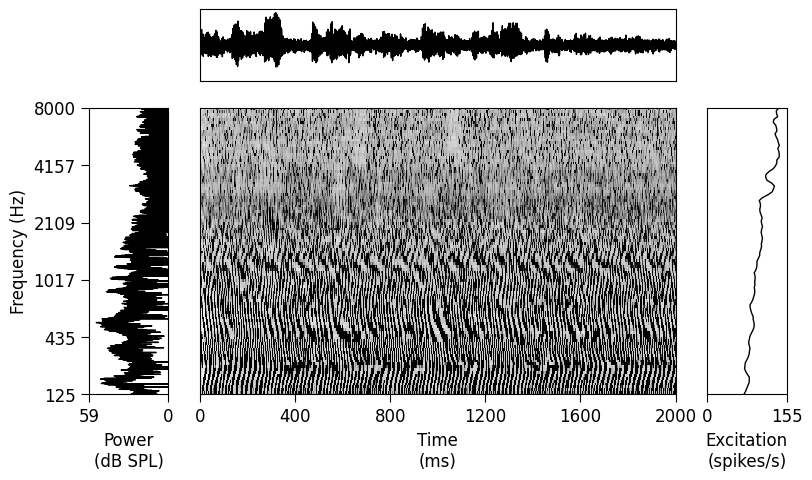

In [15]:
import utils
nervegram = nervegram_output_dict['nervegram_meanrates']

# Make sure the original acoustic waveform is 1D so it can be plotted above or
# alongside the nervegram. This helps connect the neural representation back to
# the original sound pressure waveform.
waveform_1d = waveform.numpy().squeeze()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform_1d,
    nervegram=nervegram,
    sr_waveform=nervegram_output_dict['signal_fs'],
    sr_nervegram=nervegram_output_dict['nervegram_fs'],
    cfs=nervegram_output_dict['cf_list'],
)
plt.show()